In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [2]:
df = pd.read_csv('heart.csv')

In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [6]:
print(df['target'].value_counts())

target
1    526
0    499
Name: count, dtype: int64


<Axes: >

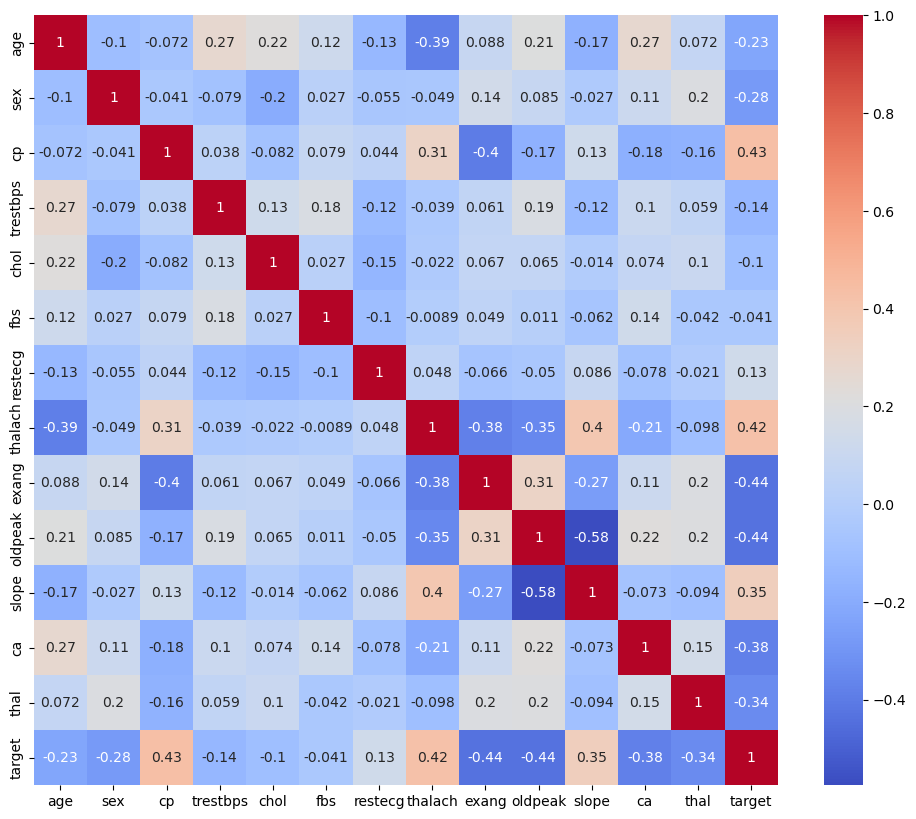

In [9]:
corr=df.corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, cmap='coolwarm')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [14]:
x=df.drop('target',axis=1)
y=df['target']

In [15]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [16]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [33]:
model = LogisticRegression(max_iter=1000,
                           class_weight='balanced',)
model.fit(x_train_scaled, y_train)
y_pred = model.predict(x_test_scaled)
y_prob = model.predict_proba(x_test_scaled)[:,1]
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("Predicted probabilities for the positive class:", y_prob)

              precision    recall  f1-score   support

           0       0.84      0.74      0.79       102
           1       0.77      0.86      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.80      0.80       205
weighted avg       0.80      0.80      0.80       205

[[75 27]
 [14 89]]
Predicted probabilities for the positive class: [9.73758115e-01 9.96749767e-01 1.36770246e-02 9.69815676e-01
 4.03075833e-02 6.62424922e-01 6.73501266e-03 4.07050831e-03
 8.31793236e-01 1.43026287e-02 9.78455036e-01 1.61052490e-03
 8.70454057e-01 8.63023640e-01 6.57606714e-02 9.41461216e-01
 6.40746074e-03 9.76868050e-01 7.47458863e-01 1.06635886e-02
 8.15716401e-01 4.71262220e-02 4.74367221e-01 2.34191434e-03
 8.15716401e-01 6.35046644e-01 9.78099657e-01 4.96067784e-01
 2.49885458e-03 9.09769604e-01 6.41194216e-01 8.09359964e-01
 4.90363685e-01 9.96749767e-01 8.55552352e-01 7.43725747e-01
 8.15716401e-01 3.88605958e-01 8.37542332e-01 9.43674929e

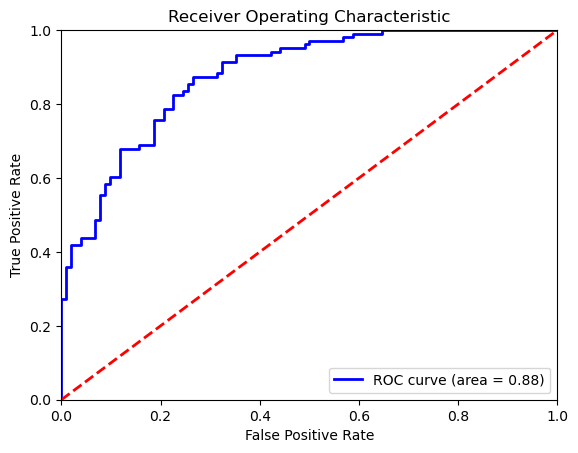

In [24]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [31]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc)

ROC-AUC: 0.8787359604035789


In [25]:
import numpy as np

j_scores = tpr - fpr

best_index = np.argmax(j_scores)

best_threshold = thresholds[best_index]

print("Best Threshold:", best_threshold)

Best Threshold: 0.5163261020189364


In [30]:
y_pred_optimal = (y_prob >= 0.3).astype(int)
print(classification_report(y_test, y_pred_optimal))
print(confusion_matrix(y_test, y_pred_optimal))

              precision    recall  f1-score   support

           0       0.90      0.64      0.75       102
           1       0.72      0.93      0.81       103

    accuracy                           0.79       205
   macro avg       0.81      0.78      0.78       205
weighted avg       0.81      0.79      0.78       205

[[65 37]
 [ 7 96]]


In [32]:
from sklearn.model_selection import GridSearchCV

In [37]:
params = [
    {
        'penalty': ['l1'],
        'solver': ['liblinear', 'saga'],
        'C': [0.001, 0.01, 0.1, 1, 10]
    },

    {
        'penalty': ['l2'],
        'solver': ['lbfgs', 'liblinear', 'newton-cg', 'sag', 'saga'],
        'C': [0.001, 0.01, 0.1, 1, 10]
    },

    {
        'penalty': ['elasticnet'],
        'solver': ['saga'],
        'C': [0.001, 0.01, 0.1, 1, 10],
        'l1_ratio': [0.5]
    }
]

In [38]:
grid = GridSearchCV(
    model,
    params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(x_train_scaled, y_train)

print(grid.best_params_)

{'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}


In [40]:
best_model = grid.best_estimator_
print("Best Model:", best_model)

Best Model: LogisticRegression(C=10, class_weight='balanced', max_iter=1000,
                   solver='liblinear')


In [41]:
best_model.fit(x_train_scaled, y_train)
y_pred = best_model.predict(x_test_scaled)
y_prob = best_model.predict_proba(x_test_scaled)[:,1]
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.74      0.79       102
           1       0.77      0.86      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.80      0.80       205
weighted avg       0.80      0.80      0.80       205

[[75 27]
 [14 89]]


In [42]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', best_model)
])

In [45]:
pipeline.fit(x_train, y_train)
y_pred_pipeline = pipeline.predict(x_test)
y_prob_pipeline = pipeline.predict_proba(x_test)[:,1]
print(classification_report(y_test, y_pred_pipeline))
print(confusion_matrix(y_test, y_pred_pipeline))

              precision    recall  f1-score   support

           0       0.84      0.74      0.79       102
           1       0.77      0.86      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.80      0.80       205
weighted avg       0.80      0.80      0.80       205

[[75 27]
 [14 89]]


In [44]:
threshold = 0.35

y_pred = (y_prob >= threshold).astype(int)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.66      0.75       102
           1       0.73      0.91      0.81       103

    accuracy                           0.79       205
   macro avg       0.81      0.78      0.78       205
weighted avg       0.80      0.79      0.78       205

[[67 35]
 [ 9 94]]


In [46]:
#new data checking
new_data = [[
    52,   # age
    1,    # sex
    2,    # cp
    130,  # trestbps
    250,  # chol
    0,    # fbs
    1,    # restecg
    170,  # thalach
    0,    # exang
    1.2,  # oldpeak
    2,    # slope
    0,    # ca
    2     # thal
]]
prediction = pipeline.predict(new_data)

print(prediction)


[1]


c:\Users\chakr\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [49]:
x_train.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
835,49,1,2,118,149,0,0,126,0,0.8,2,3,2
137,64,0,0,180,325,0,1,154,1,0.0,2,0,2
534,54,0,2,108,267,0,0,167,0,0.0,2,0,2
495,59,1,0,135,234,0,1,161,0,0.5,1,0,3
244,51,1,2,125,245,1,0,166,0,2.4,1,0,2


In [50]:
import pickle
pickle.dump(pipeline, open('heart_disease_model.pkl', 'wb'))